# Fundamento 3 — Entrenamiento y construcción del modelo

## Explicación

Reproduce, dentro de un notebook, las 4 etapas de entrenamiento descritas en [`03-entrenamiento-modelo.md`](03-entrenamiento-modelo.md): entrenar → evaluar → validar (cross-validation) → ajustar hiperparámetros (tuning).

Requiere haber corrido antes [Fundamento 2](02-preparacion-de-datos.ipynb) (o el pipeline en `02-phase-1-local-dev-mlops/src/data_preparation/`), ya que se parte de `train.csv`/`test.csv`.

## Por qué es importante

Entrenar un modelo es solo el primer paso: hay que **medir qué tan bien predice** (evaluación), confirmar que **no memorizó** los datos de entrenamiento (validación cruzada) y **ajustar su configuración** para mejorar la métrica que más importa en este caso de uso (tuning). Sin estos pasos, no hay forma de saber si el modelo es confiable antes de ponerlo en producción.

## Mapa del notebook (para no perderse)

Todo el notebook es una sola idea repetida: **entrenar algo, medirlo y quedarnos con la mejor versión**. Estas son las paradas del camino:

| Sección | Qué pasa ahí | Qué obtienes |
|---|---|---|
| 0. Preparativos | Importar librerías y definir rutas | Nada visible, solo deja todo listo |
| Cargar train/test | Leer los CSV del Fundamento 2 y separar features (`X`) del target (`y`) | `X_train`, `y_train`, `X_test`, `y_test` |
| 1. Entrenamiento | Construir el `Pipeline` (escalado + Regresión Logística) y llamar a `.fit()` | `pipeline` ya entrenado |
| 2. Evaluación | Predecir sobre datos nunca vistos y calcular métricas | Accuracy, precision, **recall**, F1, ROC-AUC, matriz de confusión |
| 2b. Importancia de features | Mirar qué variables pesan más en la decisión | Gráfico de coeficientes |
| 3. Validación cruzada | Repetir el experimento 5 veces con particiones distintas | 5 recalls: ¿es estable el modelo? |
| 4. Tuning | Probar combinaciones de hiperparámetros y quedarse con la mejor | `tuned_pipeline` |
| Guardar artefactos | Serializar el modelo y las métricas | `artifacts/model.pkl` + `artifacts/metrics.json` |
| Probar con un empleado | Usar el modelo entrenado sobre un caso nuevo (inferencia) | Probabilidad de que se vaya |

> **Regla de oro para no perderse:** el objeto `pipeline` (y luego `tuned_pipeline`) es *el modelo*. Todo lo demás son datos que entran o números que salen de él.

## Las 3 palabras que hay que tener claras antes de empezar

| Palabra | Qué es aquí | Ejemplo en este notebook |
|---|---|---|
| **Features (`X`)** | Las columnas que describen al empleado | Años en la empresa, horas extra, satisfacción… |
| **Target (`y`)** | La columna que queremos predecir | `Attrition`: 0 = se queda, 1 = se va |
| **Pipeline** | Preprocesamiento + modelo unidos en un solo objeto | `StandardScaler` → `LogisticRegression` |

## Librerías que usamos

| Librería | Para qué la usamos aquí |
|---|---|
| `pathlib.Path` (estándar) | Rutas de archivo multiplataforma |
| `json` (estándar) | Guardar las métricas del modelo en un archivo `.json` legible |
| `joblib` | Serializar (guardar/cargar) el pipeline de scikit-learn entrenado como `.pkl` |
| `numpy` | Operaciones numéricas (redondeo de arrays de scores) |
| `pandas` | Cargar `train.csv`/`test.csv` y armar el DataFrame del empleado de ejemplo |
| `matplotlib.pyplot` | Graficar la importancia de cada feature |
| `sklearn.compose.ColumnTransformer` | Aplicar una transformación (escalado) solo a un subconjunto de columnas |
| `sklearn.pipeline.Pipeline` | Encadenar preprocesamiento + modelo en un solo objeto reproducible |
| `sklearn.preprocessing.StandardScaler` | Escalar columnas numéricas (media 0, desviación estándar 1) |
| `sklearn.linear_model.LogisticRegression` | El algoritmo de clasificación que aprende a predecir "Attrition" |
| `sklearn.model_selection` (`StratifiedKFold`, `cross_val_score`, `GridSearchCV`) | Validación cruzada y búsqueda de hiperparámetros |
| `sklearn.metrics` | Calcular accuracy, precision, recall, F1, ROC-AUC, matriz de confusión |

## Comandos / funciones clave de este notebook

| Comando | Qué hace |
|---|---|
| `ColumnTransformer(transformers=[...])` | Aplica transformaciones distintas a distintas columnas de `X` |
| `Pipeline([...])` | Une varios pasos (preprocesador, clasificador) en un solo objeto `.fit()`/`.predict()` |
| `pipeline.fit(X, y)` | Entrena el pipeline completo con los datos de entrenamiento |
| `pipeline.predict(X)` | Genera predicciones (0/1) para datos nuevos |
| `pipeline.predict_proba(X)` | Genera probabilidades `[P(clase 0), P(clase 1)]` en vez de una clase fija |
| `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `roc_auc_score` | Métricas de clasificación sobre `y_test` vs. `y_pred` |
| `confusion_matrix(...)` | Tabla de aciertos/errores por clase |
| `StratifiedKFold(n_splits=5, ...)` | Divide los datos en 5 particiones manteniendo el balance de clases en cada una |
| `cross_val_score(...)` | Entrena y evalúa el pipeline en cada partición de la validación cruzada |
| `GridSearchCV(pipeline, param_grid, ...)` | Prueba todas las combinaciones de `param_grid` y se queda con la de mejor score |
| `joblib.dump(obj, ruta)` | Serializa un objeto de Python (el pipeline entrenado) a un archivo `.pkl` |
| `json.dump(dict, f)` | Escribe un diccionario de Python como archivo `.json` |

Guía de referencia: [`03-entrenamiento-modelo.md`](03-entrenamiento-modelo.md)


## 0. Preparativos: importar librerías y definir rutas

Esta celda **no entrena ni calcula nada**: solo deja el entorno listo. Hace tres cosas:

1. **Importa** todo lo que se usará después (pandas para los datos, scikit-learn para el modelo y las métricas, joblib para guardar el resultado).
2. **Define dónde están los datos**: `PROCESSED_DIR` apunta a la carpeta donde el Fundamento 2 dejó `train.csv` y `test.csv`.
3. **Define dónde se guardarán los resultados**: `ARTIFACT_DIR` es la carpeta `artifacts/` de *este* notebook, que se crea si no existe.

> ¿Por qué dos carpetas de artefactos? La carpeta `artifacts/` de este notebook es para practicar. El `model.pkl` que consume de verdad la API de inferencia (Fundamento 4) vive en `02-phase-1-local-dev-mlops/artifacts/`, y se genera con los scripts de esa carpeta. Así, experimentar aquí nunca rompe el modelo que está "en producción".

**Si esta celda falla:** casi siempre es el kernel equivocado (`ModuleNotFoundError`). Selecciona el `.venv` de esta carpeta como kernel y vuelve a ejecutarla.


In [1]:
from pathlib import Path  # rutas de archivo multiplataforma
import json  # guardar las métricas del modelo en un archivo legible
import joblib  # serializar (guardar/cargar) el pipeline entrenado
import numpy as np  # operaciones numéricas de apoyo
import pandas as pd  # carga y manipulación de datos tabulares
import matplotlib.pyplot as plt  # gráfico de importancia de features
from sklearn.compose import ColumnTransformer  # aplica una transformación solo a ciertas columnas
from sklearn.pipeline import Pipeline  # encadena preprocesamiento + modelo en un solo objeto
from sklearn.preprocessing import StandardScaler  # escala columnas numéricas (media 0, desviación 1)
from sklearn.linear_model import LogisticRegression  # algoritmo de clasificación usado en este curso
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV  # validación cruzada y tuning
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)  # métricas para evaluar qué tan bien predice el modelo

%matplotlib inline
# muestra los gráficos directamente debajo de cada celda

PROCESSED_DIR = Path("../02-phase-1-local-dev-mlops/datasets/processed")  # carpeta con train.csv/test.csv del Fundamento 2
# Artefactos propios de este notebook: separados de 02-phase-1-local-dev-mlops/artifacts
# (ese otro directorio es el que realmente consume la API de inferencia/KServe).
ARTIFACT_DIR = Path("artifacts")  # carpeta local donde este notebook guardará su propio model.pkl/metrics.json
ARTIFACT_DIR.mkdir(exist_ok=True)  # la crea si no existe; no falla si ya existe

## Cargar train/test (resultado del fundamento anterior)

Aquí recogemos el trabajo del Fundamento 2. Recuerda que allí el dataset se partió en dos archivos:

- **`train.csv` (80%)**: los ejemplos con los que el modelo va a *aprender*.
- **`test.csv` (20%)**: ejemplos que el modelo **no verá durante el entrenamiento**, reservados para el "examen final".

La celda siguiente hace dos operaciones que se repiten en todo proyecto de ML:

1. **Leer los CSV** con `pd.read_csv()` → obtenemos dos DataFrames (`train_df`, `test_df`).
2. **Separar `X` de `y`**: `X` son todas las columnas *menos* `Attrition` (lo que el modelo usa para decidir), e `y` es solo la columna `Attrition` (la respuesta correcta que queremos predecir). Por eso se usa `drop(columns=["Attrition"])`.

| Variable | Qué contiene | Analogía |
|---|---|---|
| `X_train` | Features de los empleados de entrenamiento | Los ejercicios del libro |
| `y_train` | Si cada uno se fue (1) o se quedó (0) | Las soluciones de esos ejercicios |
| `X_test` | Features de empleados reservados | Las preguntas del examen |
| `y_test` | Sus respuestas reales | La plantilla de corrección del examen |

**Qué mirar en la salida:** dos pares `(filas, columnas)`. El número de columnas debe ser **idéntico** en train y test (mismas features); las filas deben estar en proporción ~80/20. Si el número de columnas no coincide, algo salió mal en el Fundamento 2.


In [2]:
train_df = pd.read_csv(PROCESSED_DIR / "train.csv")  # dataset de entrenamiento (80%), generado en el Fundamento 2
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")  # dataset de prueba (20%), datos que el modelo nunca verá al entrenar

X_train, y_train = train_df.drop(columns=["Attrition"]), train_df["Attrition"]  # separa features (X) del target (y)
X_test, y_test = test_df.drop(columns=["Attrition"]), test_df["Attrition"]

print(f"train: {X_train.shape} | test: {X_test.shape}")  # confirma el tamaño de cada conjunto

train: (59598, 19) | test: (14900, 19)


## 1. Entrenamiento

Este es el corazón del notebook, y la celda tiene tres partes. Léelas en este orden:

**a) ¿Qué columnas hay que escalar?** — `NUMERIC_COLS` + `numeric_indices`

Después del Fundamento 2 casi todas las columnas ya son números pequeños (0, 1, 2, 3…), pero unas pocas están en escalas muy distintas (años, antigüedad, ratios). Si no las igualamos, la Regresión Logística le daría más peso a la columna con números más grandes solo por ser más grande. Por eso listamos esas columnas y convertimos sus nombres a posiciones con `get_loc()`, que es el formato que espera el `ColumnTransformer`.

**b) ¿Cómo aplico el escalado solo a esas columnas?** — `ColumnTransformer`

Aplica `StandardScaler` (dejar cada columna con media 0 y desviación 1) **únicamente** a las columnas listadas, y `remainder="passthrough"` deja el resto pasar tal cual, sin tocarlas.

**c) ¿Cómo uno preprocesamiento y modelo?** — `Pipeline`

Un `Pipeline` encadena pasos: primero `preprocessor`, luego `classifier`. La ventaja es enorme: cuando más adelante llames a `.predict()` con un empleado nuevo, el escalado se aplicará **automáticamente y exactamente igual** que durante el entrenamiento. Es lo que evita el error clásico de entrenar con datos escalados y predecir con datos sin escalar.

```
X  →  [ StandardScaler en 4 columnas ]  →  [ LogisticRegression ]  →  0 / 1
        \_________________________ Pipeline __________________________/
```

**¿Y `class_weight="balanced"`?** En el dataset hay muchos más empleados que se quedan que empleados que se van. Sin este ajuste, el modelo aprendería el atajo "digo que todos se quedan" y acertaría bastante… sin servir para nada. `balanced` hace que equivocarse con la clase minoritaria (los que se van) "duela" más, que es justo lo que queremos.

**Lo único que realmente entrena es `pipeline.fit(X_train, y_train)`**: ahí el algoritmo recorre los ejemplos y ajusta sus pesos. Al terminar, el objeto `pipeline` ya no es una receta vacía: es un modelo entrenado.

**Qué mirar en la salida:** solo el mensaje "Modelo entrenado." — el entrenamiento no imprime métricas, eso llega en la sección 2. Si aparece un aviso de convergencia, significa que el solver necesitaría más iteraciones; no es un error.


In [3]:
NUMERIC_COLS = ["Years at Company", "Company Tenure", "RoleStagnationRatio", "TenureGap"]  # únicas columnas que necesitan escalado
numeric_indices = [X_train.columns.get_loc(c) for c in NUMERIC_COLS]  # convierte los nombres a posiciones (índices) de columna

# ColumnTransformer aplica StandardScaler SOLO a las columnas numéricas listadas;
# remainder="passthrough" deja el resto de columnas (ya codificadas como enteros) sin tocar
preprocessor = ColumnTransformer(
    transformers=[("scaler", StandardScaler(), numeric_indices)],
    remainder="passthrough",
)

# El Pipeline encadena el preprocesador y el clasificador: al llamar .fit()/.predict() se ejecutan ambos pasos en orden
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced")),  # class_weight="balanced" compensa que hay más "Stayed" que "Left"
])

pipeline.fit(X_train, y_train)  # entrena: primero escala X_train, luego ajusta los pesos de la regresión logística
print("Modelo entrenado.")

Modelo entrenado.


## 2. Evaluación

Entrenar es la parte fácil. Ahora toca el examen: `pipeline.predict(X_test)` genera predicciones sobre empleados que el modelo **nunca vio**, y las comparamos con las respuestas reales (`y_test`).

### Las métricas, en lenguaje llano

| Métrica | La pregunta que responde | Cuándo importa |
|---|---|---|
| **Accuracy** | De todas las predicciones, ¿cuántas acerté? | Engañosa si una clase es mucho más frecuente que la otra |
| **Precision** | Cuando digo "se va", ¿cuántas veces acierto? | Si dar falsas alarmas es caro |
| **Recall** | De todos los que realmente se fueron, ¿a cuántos detecté? | **La métrica clave aquí**: no queremos que se nos escape nadie |
| **F1** | Un solo número que equilibra precision y recall | Para comparar modelos de un vistazo |
| **ROC-AUC** | ¿Qué tan bien separa el modelo a los dos grupos? | Mide la calidad del ranking, independiente del umbral 0.5 |

> **Por qué recall manda en este caso de uso:** el error caro es decir "se queda" sobre alguien que renuncia (falso negativo), porque RRHH no hace nada y pierde a la persona. Una falsa alarma solo cuesta una conversación de más.

### Cómo leer la matriz de confusión

Se imprime como una tabla de 2×2 con este significado:

|  | Predijo "se queda" (0) | Predijo "se va" (1) |
|---|---|---|
| **Realmente se quedó (0)** | Verdadero negativo ✅ | Falso positivo ⚠️ (falsa alarma) |
| **Realmente se fue (1)** | **Falso negativo ❌ (el error caro)** | Verdadero positivo ✅ |

**Qué mirar en la salida:** primero el **recall** (esperable ~0.7); después, en la matriz de confusión, la casilla de abajo a la izquierda: son las personas que se fueron y el modelo no vio venir. El `classification_report` repite precision/recall/F1 para cada clase por separado, útil para ver si el modelo es bueno con una clase y malo con la otra.


In [4]:
y_pred = pipeline.predict(X_test)  # predicciones (0/1) del modelo sobre datos que nunca vio durante el entrenamiento

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")  # % total de predicciones correctas
print(f"Precision: {precision_score(y_test, y_pred):.4f}")  # de los que predijo "se va", cuántos realmente se fueron
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")  # de los que realmente se fueron, cuántos detectó el modelo (la métrica clave aquí)
print(f"F1:        {f1_score(y_test, y_pred):.4f}")  # promedio armónico entre precision y recall
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred):.4f}")  # qué tan bien separa el modelo la clase positiva de la negativa
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))  # tabla de verdaderos/falsos positivos y negativos
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))  # resumen de precision/recall/F1 por cada clase

Accuracy:  0.6858
Precision: 0.6564
Recall:    0.7099
F1:        0.6821
ROC-AUC:   0.6870

Matriz de confusión:
[[5197 2629]
 [2052 5022]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.72      0.66      0.69      7826
           1       0.66      0.71      0.68      7074

    accuracy                           0.69     14900
   macro avg       0.69      0.69      0.69     14900
weighted avg       0.69      0.69      0.69     14900



### 2b. ¿En qué se fija el modelo? (importancia de features)

Las métricas dicen *qué tan bien* predice, pero no *por qué*. Como usamos Regresión Logística, podemos abrir el modelo y mirar sus **coeficientes**: un número por cada feature, que es exactamente el "peso" que aprendió durante el entrenamiento.

Qué hace la celda siguiente, paso a paso:

1. `get_feature_names(...)`: el `ColumnTransformer` reordena las columnas internamente (primero las escaladas, luego el resto), así que esta función recupera los nombres **en el mismo orden** que usa el modelo. Sin esto, asociaríamos cada coeficiente a la columna equivocada.
2. `.coef_[0]`: extrae los pesos aprendidos por la Regresión Logística.
3. Se arma un DataFrame `feature → coeficiente`, se ordena por valor absoluto (magnitud, sin importar el signo) y se dibuja en un gráfico de barras horizontales.

**Cómo leer el gráfico:**

- Barra **hacia la derecha (positiva)** → esa feature **aumenta** la probabilidad de que el empleado se vaya.
- Barra **hacia la izquierda (negativa)** → **reduce** esa probabilidad.
- **Barra más larga = más influencia** en la decisión final.

> Esto es lo que en el mundo real permite explicarle a RRHH *por qué* el modelo señaló a alguien. Ojo con la trampa clásica: los coeficientes muestran **asociación, no causalidad** — que "horas extra" pese mucho no demuestra que las horas extra causen la renuncia.


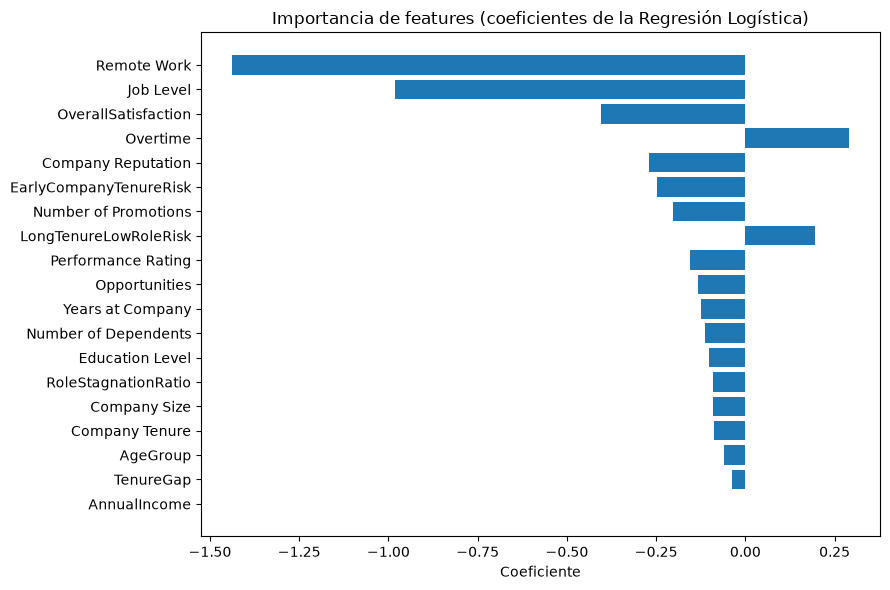

In [5]:
def get_feature_names(pipeline, original_columns):
    """Nombres de features en el orden que produce el ColumnTransformer."""
    ct = pipeline.named_steps["preprocessor"]  # accede al paso "preprocessor" dentro del Pipeline
    names = []
    for _, _, indices in ct.transformers_:  # transformers_ trae (nombre, transformador, índices) ya aplicados
        names.extend([original_columns[i] for i in indices])  # traduce cada índice de vuelta a su nombre de columna
    return names


feature_names = get_feature_names(pipeline, X_train.columns.tolist())  # nombres en el mismo orden que usa el modelo internamente
coef = pipeline.named_steps["classifier"].coef_[0]  # coeficientes aprendidos por la Regresión Logística (uno por feature)
coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coef})  # tabla feature -> coeficiente
coef_df["Abs"] = coef_df["Coefficient"].abs()  # valor absoluto, para ordenar por magnitud sin importar el signo
coef_df = coef_df.sort_values("Abs", ascending=False)  # de mayor a menor influencia sobre la predicción

plt.figure(figsize=(9, 6))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])  # gráfico de barras horizontales, una por feature
plt.gca().invert_yaxis()  # invierte el eje Y para que la feature más importante quede arriba
plt.title("Importancia de features (coeficientes de la Regresión Logística)")
plt.xlabel("Coeficiente")  # positivo = aumenta la probabilidad de "Left"; negativo = la reduce
plt.tight_layout()  # ajusta márgenes para que las etiquetas largas no se corten
plt.show()

## 3. Validación cruzada

El recall de la sección 2 salió de **una sola** división de los datos. ¿Y si tuvimos suerte con esa partición concreta? La validación cruzada responde a eso repitiendo el experimento varias veces.

**Cómo funciona (5 folds):** se parte `X_train` en 5 trozos; se entrena con 4 y se evalúa con el que quedó fuera; se repite rotando cuál es el trozo de evaluación. Resultado: 5 recalls independientes.

```
Fold 1:  [test][train][train][train][train]
Fold 2:  [train][test][train][train][train]
Fold 3:  [train][train][test][train][train]
Fold 4:  [train][train][train][test][train]
Fold 5:  [train][train][train][train][test]
```

**Por qué `StratifiedKFold` y no una división cualquiera:** "estratificado" significa que cada trozo mantiene la misma proporción de empleados que se van y que se quedan. Sin eso, un fold podría quedarse casi sin casos de la clase minoritaria y su recall no significaría nada. `shuffle=True` mezcla antes de partir, y `random_state=42` hace que el resultado sea reproducible (siempre las mismas particiones).

**Qué mirar en la salida:**

- **El promedio** → el rendimiento esperable del modelo.
- **La desviación (`+/-`) y los 5 scores individuales** → esto es lo importante. Valores parecidos entre sí = modelo **estable**, que aprendió patrones reales. Valores muy dispares (por ejemplo 0.45 y 0.85) = el resultado depende de la suerte de la partición, señal de alarma.

> Nota: esto usa **solo `X_train`**. El `test.csv` sigue intacto y reservado para la evaluación final: si lo usáramos aquí, dejaría de ser un examen limpio.


In [6]:
strat_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5 particiones, mezcladas, manteniendo el balance de clases en cada una
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=strat_cv, scoring="recall")  # entrena y evalúa el pipeline 5 veces, midiendo recall

print(f"Recall promedio (5 folds): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")  # promedio y variabilidad entre folds
print(f"Scores por fold: {np.round(cv_scores, 4)}")  # el recall obtenido en cada una de las 5 particiones

Recall promedio (5 folds): 0.7064 (+/- 0.0051)
Scores por fold: [0.697  0.7086 0.7111 0.71   0.7054]


## 4. Ajuste de hiperparámetros (Tuning)

Hasta ahora usamos la configuración por defecto de la Regresión Logística. Los **hiperparámetros** son las opciones que se eligen *antes* de entrenar (a diferencia de los pesos, que el modelo aprende solo). `GridSearchCV` prueba combinaciones y se queda con la mejor, medida con recall.

**Qué significa cada hiperparámetro del `param_grid`:**

| Hiperparámetro | Qué controla | Efecto |
|---|---|---|
| `C` | Cuánta regularización se aplica | Valores **bajos** (0.01) = modelo más simple y prudente; valores **altos** (100) = más libre para ajustarse a los datos (riesgo de overfitting) |
| `solver` | El algoritmo que busca los pesos óptimos | `liblinear` y `saga` son dos estrategias distintas; se comparan para ver cuál va mejor con estos datos |
| `max_iter` | Cuántas iteraciones puede usar el solver | Suficientes para que converja sin quedarse a medias |

**Ojo al prefijo `classifier__`:** el doble guion bajo significa "el parámetro `C` del paso llamado `classifier` dentro del Pipeline". Así se le indica a `GridSearchCV` a qué paso concreto pertenece cada opción.

**Cuánto trabajo hace esta celda:** 5 valores de `C` × 2 solvers = 10 combinaciones, y cada una se evalúa con la validación cruzada de 5 folds → **50 entrenamientos**. Por eso esta celda tarda más que las demás; es normal.

**Qué mirar en la salida:**

- `Mejores hiperparámetros` → la combinación ganadora.
- `Mejor recall (CV)` → el recall promedio que logró. Compáralo con el de la sección 3: así ves si el tuning realmente aportó algo o si la mejora fue mínima.

> `grid.best_estimator_` (guardado en `tuned_pipeline`) ya viene **re-entrenado con todos los datos de entrenamiento** usando la mejor combinación. No hay que volver a llamar a `.fit()`.


In [7]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],  # fuerza de regularización a probar (valores bajos = más regularización)
    "classifier__solver": ["liblinear", "saga"],  # algoritmos de optimización a comparar
    "classifier__max_iter": [1000],  # iteraciones máximas para que el solver converja
}

# GridSearchCV prueba TODAS las combinaciones de param_grid, usando la misma validación cruzada de arriba,
# y se queda con la combinación que obtiene mejor recall promedio
grid = GridSearchCV(pipeline, param_grid=param_grid, cv=strat_cv, scoring="recall")
grid.fit(X_train, y_train)  # ejecuta la búsqueda completa (entrena 5 folds x 10 combinaciones = 50 entrenamientos)

tuned_pipeline = grid.best_estimator_  # el pipeline ya re-entrenado con la mejor combinación de hiperparámetros
print(f"Mejores hiperparámetros: {grid.best_params_}")  # qué combinación ganó
print(f"Mejor recall (CV): {grid.best_score_:.4f}")  # el recall promedio que obtuvo esa combinación

Mejores hiperparámetros: {'classifier__C': 10, 'classifier__max_iter': 1000, 'classifier__solver': 'saga'}
Mejor recall (CV): 0.7065


### 4b. Evaluación final y guardado de artefactos

Aquí termina la parte de ciencia de datos y empieza la parte de MLOps. La celda hace tres cosas:

1. **Evalúa el modelo ajustado** (`tuned_pipeline`) contra `X_test`, el conjunto reservado. Este es el número honesto: el modelo nunca vio esos datos, ni siquiera durante el tuning.
2. **Guarda las métricas** en `artifacts/metrics.json`. Un archivo pequeño, pero clave: en una pipeline de CI/CD real, un paso lee este JSON y **bloquea el despliegue** si el recall bajó de un umbral acordado.
3. **Serializa el modelo** con `joblib.dump()` en `artifacts/model.pkl`. "Serializar" es congelar el objeto de Python entero — preprocesador incluido — en un archivo, para poder cargarlo después en otra máquina sin volver a entrenar.

| Archivo generado | Qué contiene | Quién lo consume después |
|---|---|---|
| `artifacts/model.pkl` | El pipeline entrenado (escalado + modelo con sus pesos) | La API de inferencia del Fundamento 4 |
| `artifacts/metrics.json` | Accuracy y recall finales | La pipeline de CI/CD y el registro de experimentos (MLflow, en la Fase 2) |

> **Este es el momento que conecta las dos mitades del bootcamp.** Todo lo anterior produce estos dos archivos; todo lo que viene después (Docker, KServe, versionado, monitoreo) trata sobre cómo moverlos, versionarlos y vigilarlos. Fíjate también en lo pequeño que es el `.pkl`: unos KB, porque solo guarda ~19 pesos.


In [8]:
y_pred_tuned = tuned_pipeline.predict(X_test)  # predicciones del modelo ya ajustado (tuned), sobre el test set
metrics = {
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "recall": recall_score(y_test, y_pred_tuned),
}
print(metrics)  # métricas finales del modelo elegido

with open(ARTIFACT_DIR / "metrics.json", "w") as f:  # abre (o crea) metrics.json en modo escritura
    json.dump(metrics, f, indent=2)  # escribe el diccionario de métricas como JSON, con indentación legible

joblib.dump(tuned_pipeline, ARTIFACT_DIR / "model.pkl")  # serializa el pipeline completo (preprocesador + modelo) a disco
print(f"Modelo guardado en: {(ARTIFACT_DIR / 'model.pkl').resolve()}")  # ruta absoluta del archivo generado

{'accuracy': 0.6859060402684564, 'recall': 0.71006502685892}
Modelo guardado en: /home/jcarranzaarquitect/Documentos/Machine Learning/3-Mlops/bootcampmlops/01-fundamentosml-datascience/artifacts/model.pkl


## Probar el modelo con un empleado de ejemplo (inferencia)

**Inferencia** = usar el modelo ya entrenado para predecir sobre un caso nuevo. Es exactamente lo que hará la API del Fundamento 4 cada vez que alguien de RRHH envíe el formulario; aquí lo simulamos con un diccionario en lugar de una petición HTTP.

Puntos importantes de la celda siguiente:

- **El empleado debe venir en el mismo formato que `X_train`**: todo numérico, con las mismas columnas y calculado con las mismas fórmulas del Fundamento 2 (por eso `RoleStagnationRatio` y `TenureGap` se derivan aquí a mano). Si el formato no coincide, el modelo falla o —peor— predice cualquier cosa. Este es el problema real que resuelven los *feature stores* en la Fase 2.
- **`[X_train.columns]` reordena las columnas** para que coincidan una a una con las del entrenamiento. El orden importa: el modelo no ve nombres, ve posiciones.
- **`predict_proba()` en vez de `predict()`**: devuelve `[P(se queda), P(se va)]`, es decir dos probabilidades que suman 1. Es más útil que un simple 0/1 porque permite definir niveles de riesgo (bajo, medio, alto) y priorizar a quién atender primero.
- **El umbral de 0.5 es una decisión de negocio, no una ley.** Bajarlo a 0.35 haría que el modelo señale a más gente: subiría el recall (se escapan menos) a costa de más falsas alarmas.

**Qué mirar en la salida:** las dos probabilidades y la predicción final. **Experimento recomendado:** cambia `Overtime` a 0, o sube `OverallSatisfaction`, vuelve a ejecutar la celda y observa cómo se mueve `P(se va)`. Es la forma más rápida de entender qué aprendió el modelo — y encaja con lo que viste en el gráfico de coeficientes.


In [9]:
# Datos ya en el mismo formato "featured" que produce el Fundamento 2 (todo numérico, mismas columnas que X_train)
sample_employee = {
    "Years at Company": 0.5,
    "Performance Rating": 2,
    "Number of Promotions": 0,
    "Overtime": 1,
    "Education Level": 2,
    "Number of Dependents": 1,
    "Job Level": 1,
    "Company Size": 2,
    "Company Tenure": 1.0,
    "Remote Work": 0,
    "Company Reputation": 2,
    "OverallSatisfaction": 1,
    "Opportunities": 0,
    "AnnualIncome": 1,
    "AgeGroup": 2,
    "RoleStagnationRatio": round(0.5 / (1.0 + 1), 3),  # misma fórmula usada en feature engineering (Fundamento 2)
    "TenureGap": round(1.0 - 0.5, 2),
    "EarlyCompanyTenureRisk": 1,
    "LongTenureLowRoleRisk": 0,
}

sample_df = pd.DataFrame([sample_employee])[X_train.columns]  # arma un DataFrame de 1 fila, reordenando columnas igual que X_train
p_stay, p_leave = tuned_pipeline.predict_proba(sample_df)[0]  # probabilidad de cada clase para este empleado: [P(0), P(1)]

print(f"P(se queda) = {p_stay:.4f} | P(se va) = {p_leave:.4f}")
print("Predicción:", "Se iría" if p_leave >= 0.5 else "Se queda")  # umbral de decisión de 0.5

P(se queda) = 0.0667 | P(se va) = 0.9333
Predicción: Se iría


## Ideas clave

- Entrenar = ajustar los pesos internos del modelo a partir de ejemplos históricos.
- Recall es la métrica más relevante en este caso de uso (detectar a tiempo empleados en riesgo).
- La validación cruzada confirma que el modelo generaliza, no que memorizó los datos.
- El tuning solo cambia los hiperparámetros (la configuración previa), no la forma en que el modelo aprende.
- `artifacts/model.pkl` (de este notebook) es un pipeline completo (preprocesador + clasificador); el `model.pkl` que usa la API de inferencia en `02-phase-1-local-dev-mlops/` está además envuelto para exponer solo `.predict()` con probabilidades.

## Si te perdiste, quédate con esto

Todo el notebook cabe en cinco líneas de pseudocódigo:

```text
1. datos      = leer train.csv y test.csv          → X_train, y_train, X_test, y_test
2. modelo     = Pipeline(escalado + regresión)     → una receta vacía
3. modelo.fit(X_train, y_train)                    → ya aprendió (tiene pesos)
4. evaluar y validar sobre datos no vistos         → ¿sirve? ¿es estable? ¿se puede mejorar?
5. guardar el modelo en disco                      → model.pkl + metrics.json
```

Y el resumen de qué produjo cada sección:

| Sección | Variable/archivo que deja | Para qué se usa después |
|---|---|---|
| Cargar datos | `X_train`, `y_train`, `X_test`, `y_test` | Todo el resto del notebook |
| 1. Entrenamiento | `pipeline` | Evaluación, validación cruzada y tuning |
| 2. Evaluación | Métricas impresas + gráfico de coeficientes | Decidir si el modelo es aceptable |
| 3. Validación cruzada | `cv_scores` | Confirmar estabilidad |
| 4. Tuning | `tuned_pipeline` | El modelo definitivo |
| 4b. Guardado | `artifacts/model.pkl`, `artifacts/metrics.json` | El Fundamento 4 (API + KServe) |

## Siguiente paso

Continúa con [Fundamento 4: De Modelo a API en Vivo con KServe](04-despliegue-kserve.ipynb).
